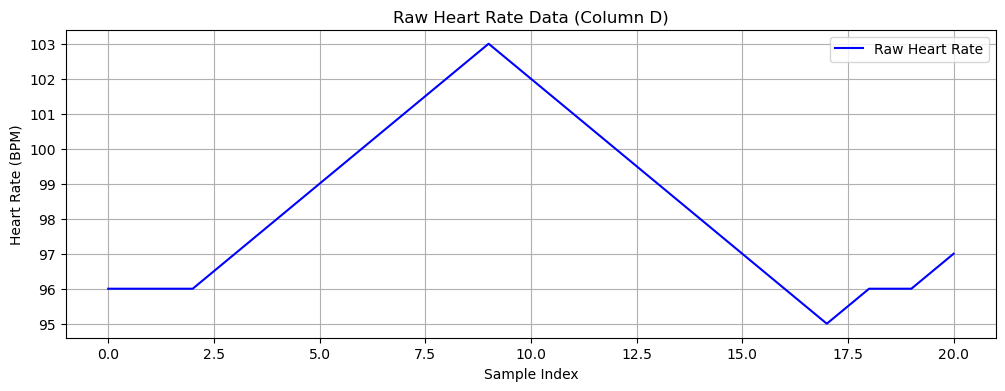

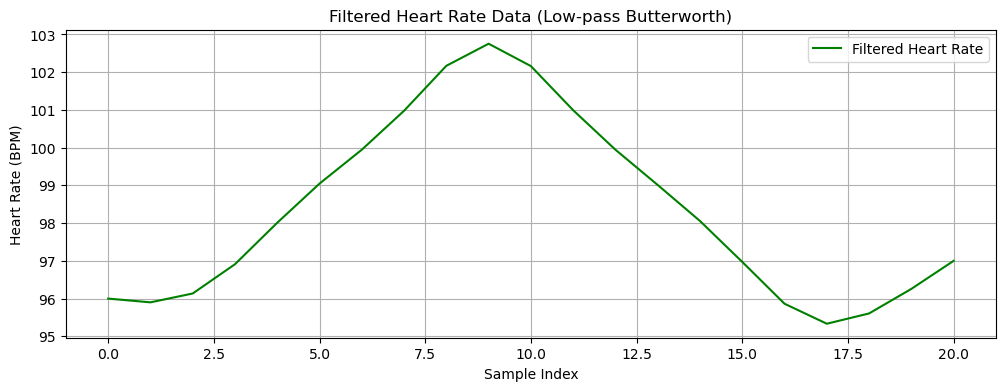

In [3]:
# Required libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Load the CSV file
file_path = "2025-04-11-064809-WAHOOAPPIOS2150-2-0-record.csv"  # adjust if needed
df = pd.read_csv(file_path)

# Extract heart rate data from column D (index 3)
heart_rate = df.iloc[:, 3].dropna().reset_index(drop=True)

# Plot raw heart rate data
plt.figure(figsize=(12, 4))
plt.plot(heart_rate, label='Raw Heart Rate', color='blue')
plt.title('Raw Heart Rate Data (Column D)')
plt.xlabel('Sample Index')
plt.ylabel('Heart Rate (BPM)')
plt.grid(True)
plt.legend()
plt.show()

# Define a low-pass Butterworth filter
def butter_lowpass_filter(data, cutoff, fs, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Filter parameters (adjust if actual sampling frequency is known)
fs = 1      # Sampling frequency in Hz
cutoff = 0.3  # Cutoff frequency for smoothing

# Apply filter
filtered_hr = butter_lowpass_filter(heart_rate.values, cutoff=cutoff, fs=fs)

# Plot filtered heart rate data
plt.figure(figsize=(12, 4))
plt.plot(filtered_hr, label='Filtered Heart Rate', color='green')
plt.title('Filtered Heart Rate Data (Low-pass Butterworth)')
plt.xlabel('Sample Index')
plt.ylabel('Heart Rate (BPM)')
plt.grid(True)
plt.legend()
plt.show()
